Model: "colorization_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8192)           │     4,202,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 8, 8, 256)      │     1,179,904 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 16, 16, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_10             │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_11             │ (None, 32, 32, 3)      │         1,731 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,220,291 (31.36 MB)

 Trainable params: 8,220,291 (31.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - loss: 0.0410 - val_loss: 0.0151
Epoch 2/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - loss: 0.0142 - val_loss: 0.0122
Epoch 3/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - loss: 0.0114 - val_loss: 0.0107
Epoch 4/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - loss: 0.0101 - val_loss: 0.0094
Epoch 5/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - loss: 0.0092 - val_loss: 0.0090
Epoch 6/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - loss: 0.0087 - val_loss: 0.0086
Epoch 7/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - loss: 0.0083 - val_loss: 0.0082
Epoch 8/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - loss: 0.0079 - val_loss: 0.0081
Epoch 9/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - loss: 0.0078 - val_loss: 0.0078
Epoch 10/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - loss: 0.0075 - val_loss: 0.0078
Epoch 11/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - loss: 0.0073 - val_loss: 0.0076
Epoch 12/30
196/196 ━━━━━━━━━━

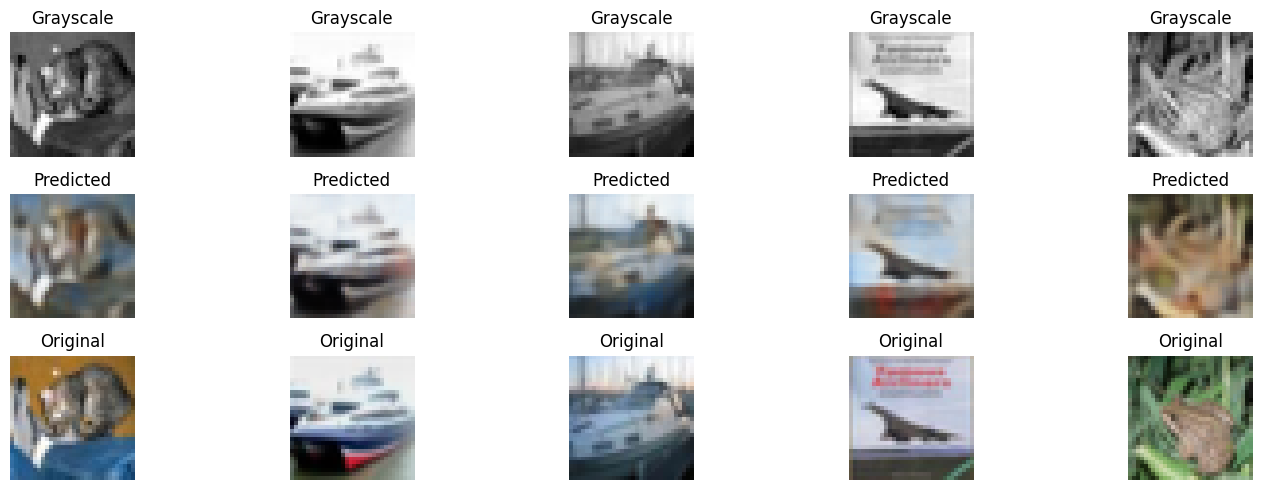

In [ ]:

import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Input, Reshape, Flatten, Conv2DTranspose
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt

# Loading and preprocessing
(x_train, _), (x_test, _) = cifar10.load_data()

# Normalization [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

#  RGB to Grayscale (Luminance formula)
def rgb2gray(rgb):
    return np.dot(rgb[...,:3], [0.2989, 0.5870, 0.1140])

x_train_gray = rgb2gray(x_train)
x_test_gray = rgb2gray(x_test)

# Reshaping to get a channel (32, 32, 1)
x_train_gray = x_train_gray.reshape(x_train_gray.shape[0], 32, 32, 1)
x_test_gray = x_test_gray.reshape(x_test_gray.shape[0], 32, 32, 1)

# Model def
input_shape = (32, 32, 1)
inputs = Input(shape=input_shape)

# Encoder
x = Conv2D(64, (3, 3), strides=2, activation='relu', padding='same')(inputs)
x = Conv2D(128, (3, 3), strides=2, activation='relu', padding='same')(x)
x = Conv2D(256, (3, 3), strides=2, activation='relu', padding='same')(x)

# Bottleneck
x = Flatten()(x)
latent = Dense(512)(x) # Latent vector
x = Dense(4 * 4 * 512)(latent)
x = Reshape((4, 4, 512))(x)

# Decoder (Upsampling με Conv2DTranspose)
x = Conv2DTranspose(256, (3, 3), strides=2, activation='relu', padding='same')(x)
x = Conv2DTranspose(128, (3, 3), strides=2, activation='relu', padding='same')(x)
x = Conv2DTranspose(64, (3, 3), strides=2, activation='relu', padding='same')(x)
outputs = Conv2DTranspose(3, (3, 3), activation='sigmoid', padding='same')(x)

# compilation
autoencoder = Model(inputs, outputs, name='colorization_autoencoder')
autoencoder.compile(loss='mse', optimizer='adam')
autoencoder.summary()

# training
autoencoder.fit(x_train_gray, x_train,
                validation_data=(x_test_gray, x_test),
                epochs=30,
                batch_size=256)

# predictions and display
predicted_imgs = autoencoder.predict(x_test_gray[:10])

plt.figure(figsize=(15, 5))
for i in range(5):
    # Grayscale Input
    ax = plt.subplot(3, 5, i + 1)
    plt.imshow(x_test_gray[i].reshape(32, 32), cmap='gray')
    plt.title("Grayscale")
    plt.axis('off')

    # Predicted Color
    ax = plt.subplot(3, 5, i + 6)
    plt.imshow(predicted_imgs[i])
    plt.title("Predicted")
    plt.axis('off')

    # Original Ground Truth
    ax = plt.subplot(3, 5, i + 11)
    plt.imshow(x_test[i])
    plt.title("Original")
    plt.axis('off')

plt.tight_layout()
plt.show()

Generating reconstructed images from Autoencoder...
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

Training CNN on ORIGINAL RGB images...
Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.2714 - loss: 1.9477 - val_accuracy: 0.5044 - val_loss: 1.3870
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4813 - loss: 1.4341 - val_accuracy: 0.5573 - val_loss: 1.2413
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5361 - loss: 1.2828 - val_accuracy: 0.5957 - val_loss: 1.1457
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5768 - loss: 1.1758 - val_accuracy: 0.6341 - val_loss: 1.0454
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6052 - loss: 1.1049 - val_accuracy: 0.6500 - val_loss: 0.9961
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6269 - loss: 1.0568 - val_accuracy: 0.6480 - val_loss: 1.0049
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6400 - loss: 1.0114 - val_accurac

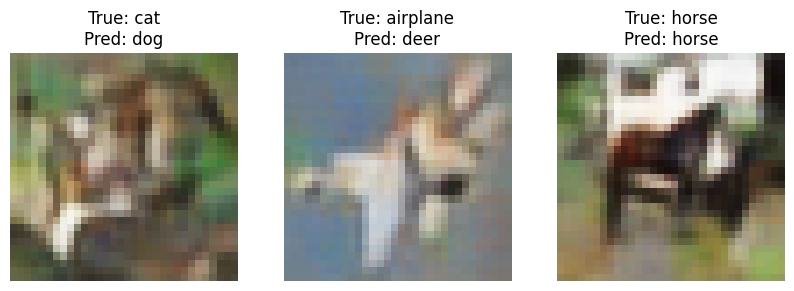

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, GlobalAveragePooling2D, Dropout


(x_train, y_train_labels), (x_test, y_test_labels) = cifar10.load_data()

x_train_rgb = x_train.astype('float32') / 255.0
x_test_rgb = x_test.astype('float32') / 255.0

#  One-Hot (for CNN)
y_train_cat = to_categorical(y_train_labels, 10)
y_test_cat = to_categorical(y_test_labels, 10)


print("Generating reconstructed images from Autoencoder...")
x_test_reconstructed = autoencoder.predict(x_test_gray, batch_size=128)

# cnn classifier
def build_classifier(input_shape=(32, 32, 3)):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same',kernel_initializer='he_normal', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu',kernel_initializer='he_normal', padding='same'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu',kernel_initializer='he_normal', padding='same'),
        MaxPooling2D((2, 2)),
        #CNN.add(layers.Flatten())
        GlobalAveragePooling2D(),
#CNN.add(layers.Dense(1024))
        Dropout(0.3),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_model = build_classifier()

print("\nTraining CNN on ORIGINAL RGB images...")
history = cnn_model.fit(x_train_rgb, y_train_cat,
                        epochs=25,
                        batch_size=64,
                        validation_data=(x_test_rgb, y_test_cat),
                        verbose=1)


# rest in Original samples
score_orig = cnn_model.evaluate(x_test_rgb, y_test_cat, verbose=0)
# test in reconstructed samples
score_recon = cnn_model.evaluate(x_test_reconstructed, y_test_cat, verbose=0)

print("\n" + "="*30)
print(f"RESULTS")
print(f"Accuracy on Original Images:      {score_orig[1]*100:.2f}%")
print(f"Accuracy on Reconstructed Images: {score_recon[1]*100:.2f}%")
print(f"Accuracy Drop:                    {(score_orig[1] - score_recon[1])*100:.2f}%")
print("="*30)

# visualize
indices = [0, 10, 20] # image samples
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10, 4))
for i, idx in enumerate(indices):
    # predictions on reconstructed images
    pred = cnn_model.predict(np.expand_dims(x_test_reconstructed[idx], axis=0))
    pred_label = class_names[np.argmax(pred)]
    true_label = class_names[np.argmax(y_test_cat[idx])]

    plt.subplot(1, 3, i+1)
    plt.imshow(x_test_reconstructed[idx])
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')
plt.show()

Υπολογισμός προβλέψεων για 10.000 εικόνες...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


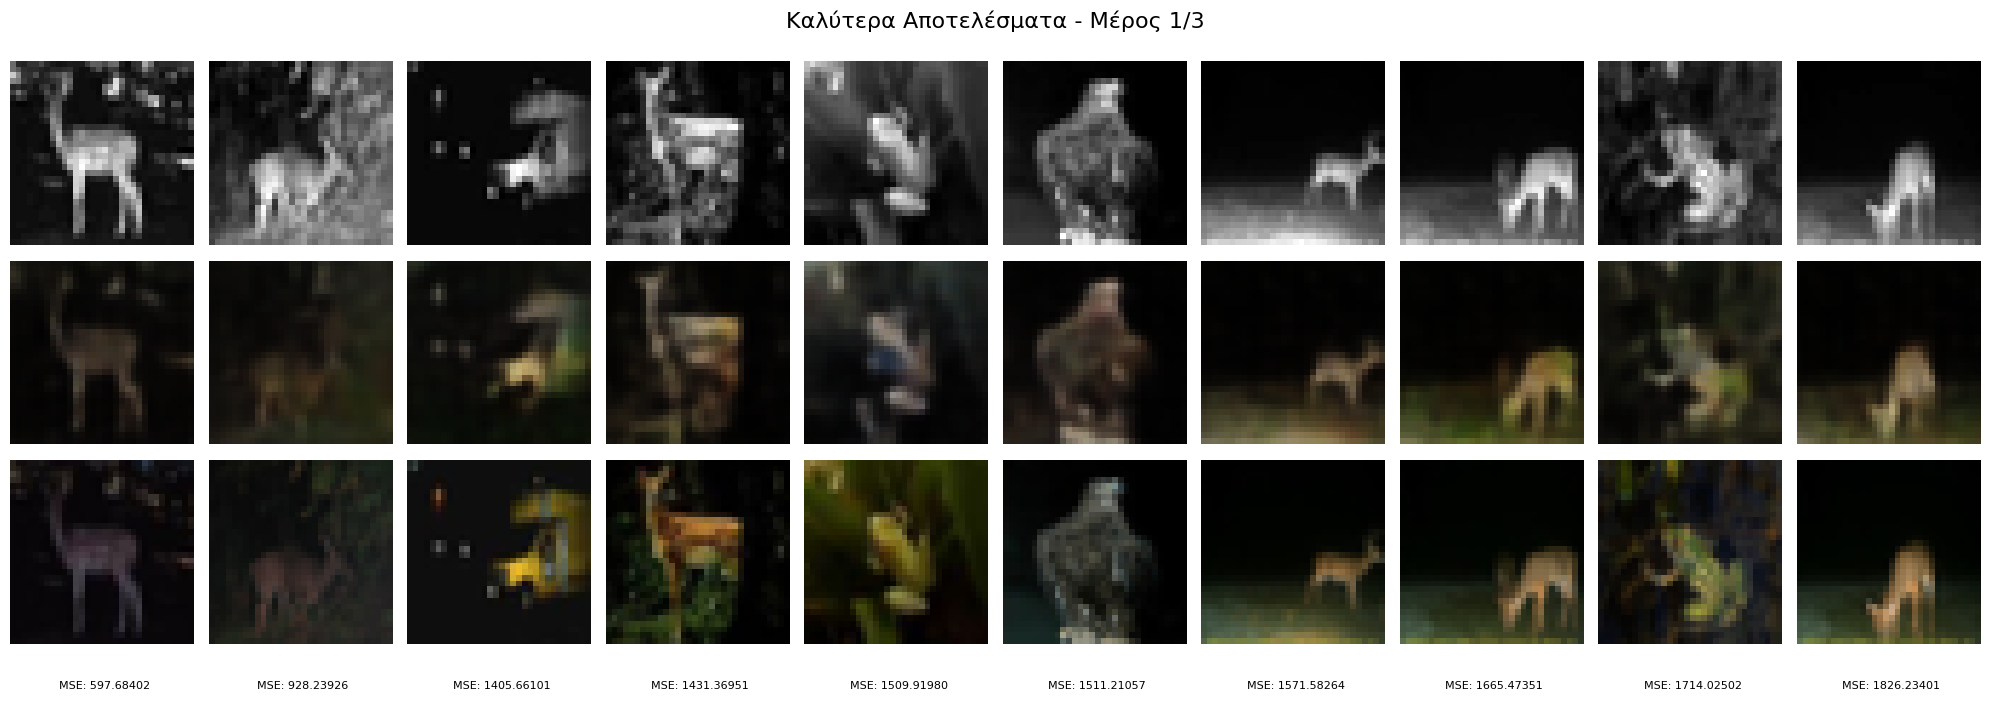

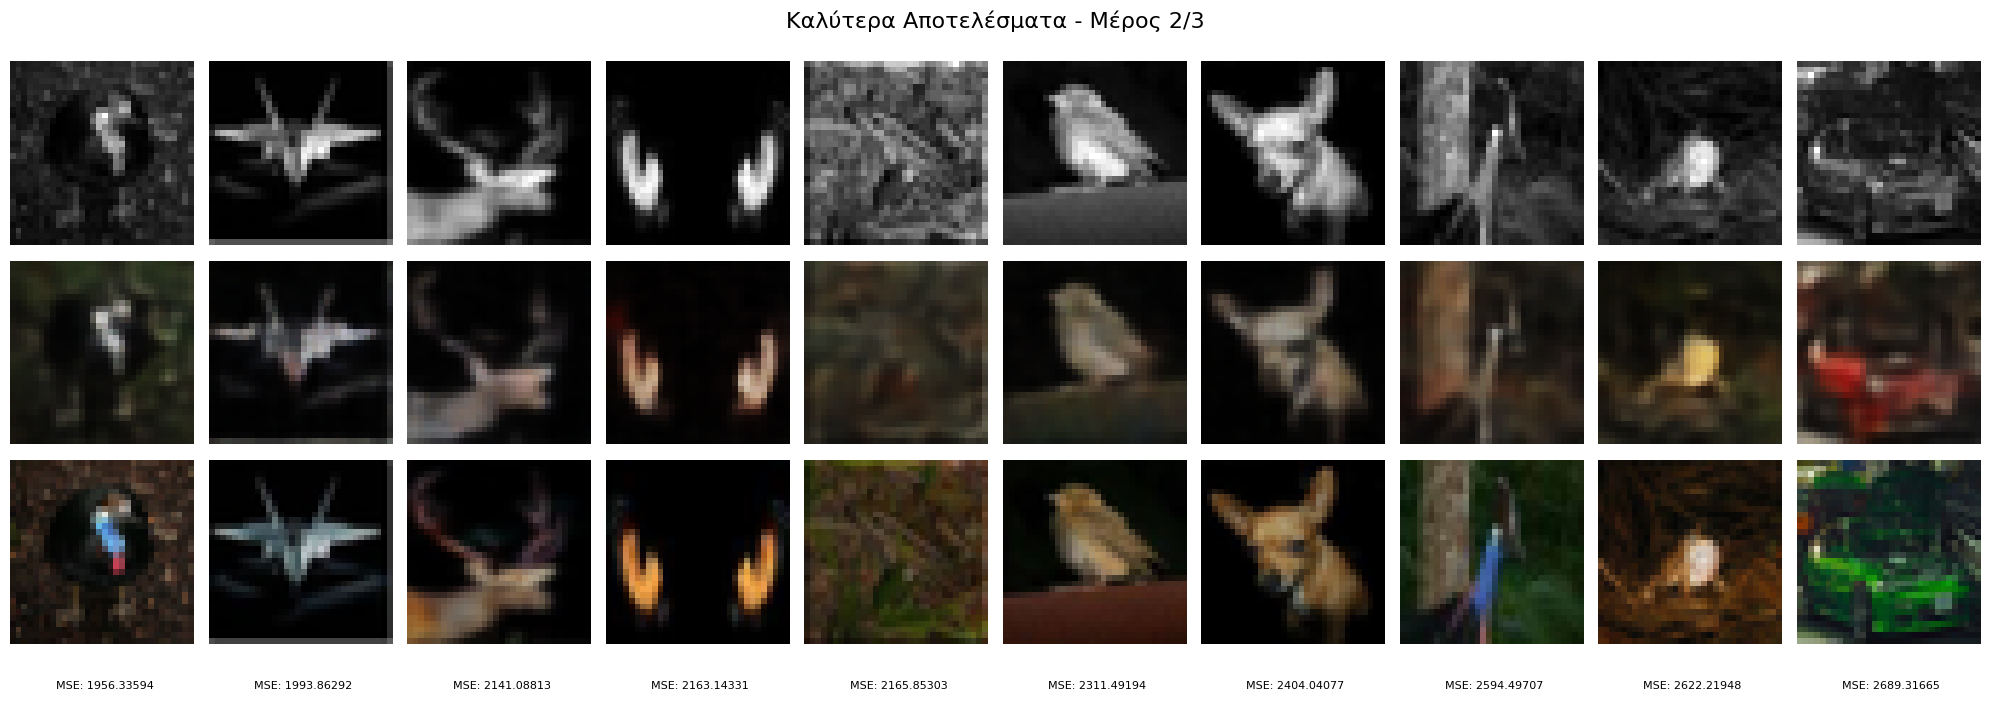

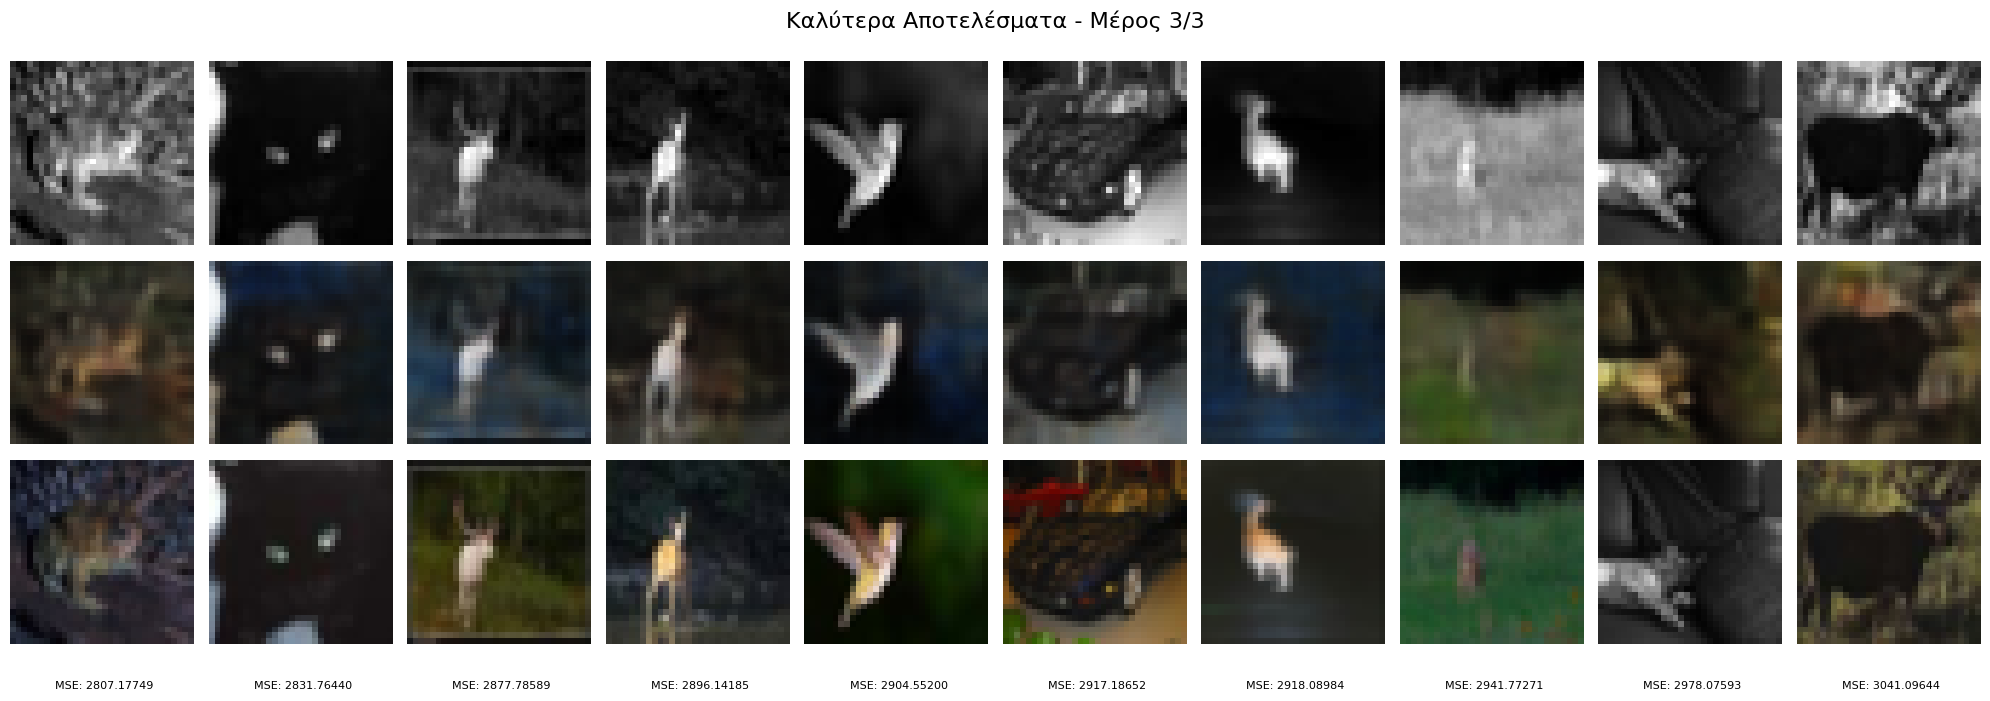

In [ ]:
# predictions on whole test set

all_predicted = autoencoder.predict(x_test_gray)


mse_per_image = np.mean(np.square(x_test - all_predicted), axis=(1, 2, 3))


best_indices = np.argsort(mse_per_image)[:30]


for block in range(3):
    plt.figure(figsize=(20, 7))
    current_indices = best_indices[block*10 : (block+1)*10]

    for i, idx in enumerate(current_indices):
        # Grayscale Input
        ax = plt.subplot(3, 10, i + 1)
        plt.imshow(x_test_gray[idx].reshape(32, 32), cmap='gray')
        if i == 0: plt.ylabel("Grayscale", fontsize=12)
        plt.axis('off')

        # Predicted Color
        ax = plt.subplot(3, 10, i + 11)
        plt.imshow(all_predicted[idx])
        if i == 0: plt.ylabel("Predicted", fontsize=12)
        plt.axis('off')

        # Original Color
        ax = plt.subplot(3, 10, i + 21)
        plt.imshow(x_test[idx])
        if i == 0: plt.ylabel("Original", fontsize=12)
        plt.axis('off')


        plt.text(16, 38, f"MSE: {mse_per_image[idx]:.5f}",
                 ha='center', va='top', fontsize=8, transform=ax.transData)

    plt.suptitle(f"Καλύτερα Αποτελέσματα - Μέρος {block+1}/3", fontsize=16)
    plt.tight_layout()
    plt.show()

Υπολογισμός προβλέψεων για 10.000 εικόνες...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


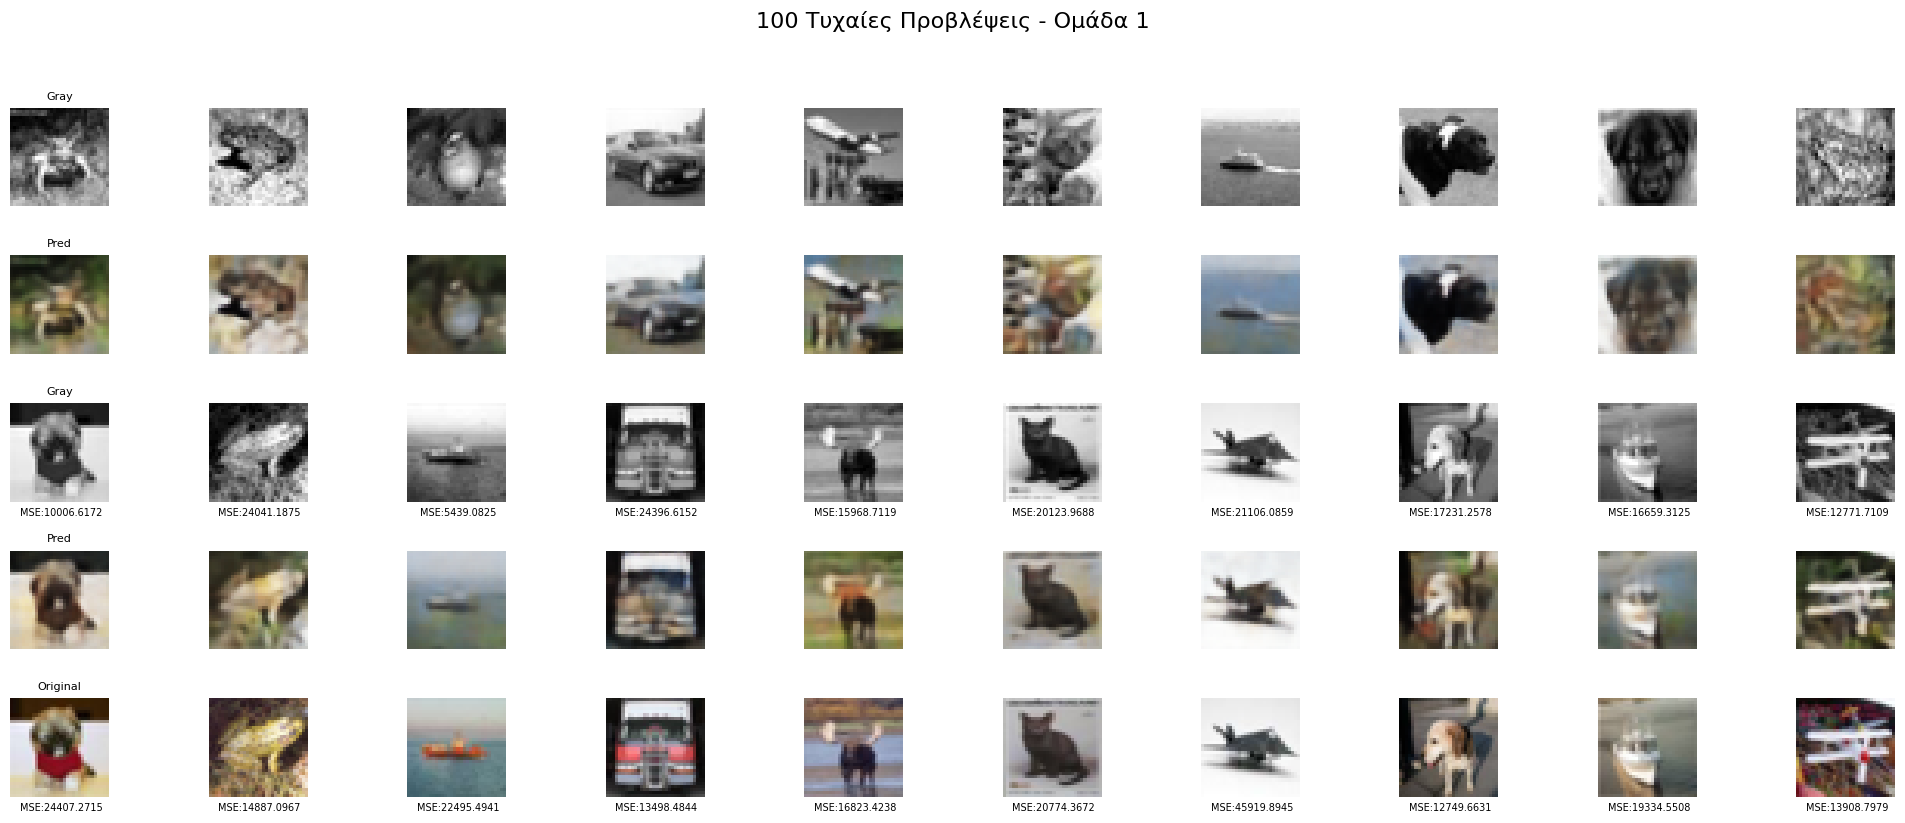

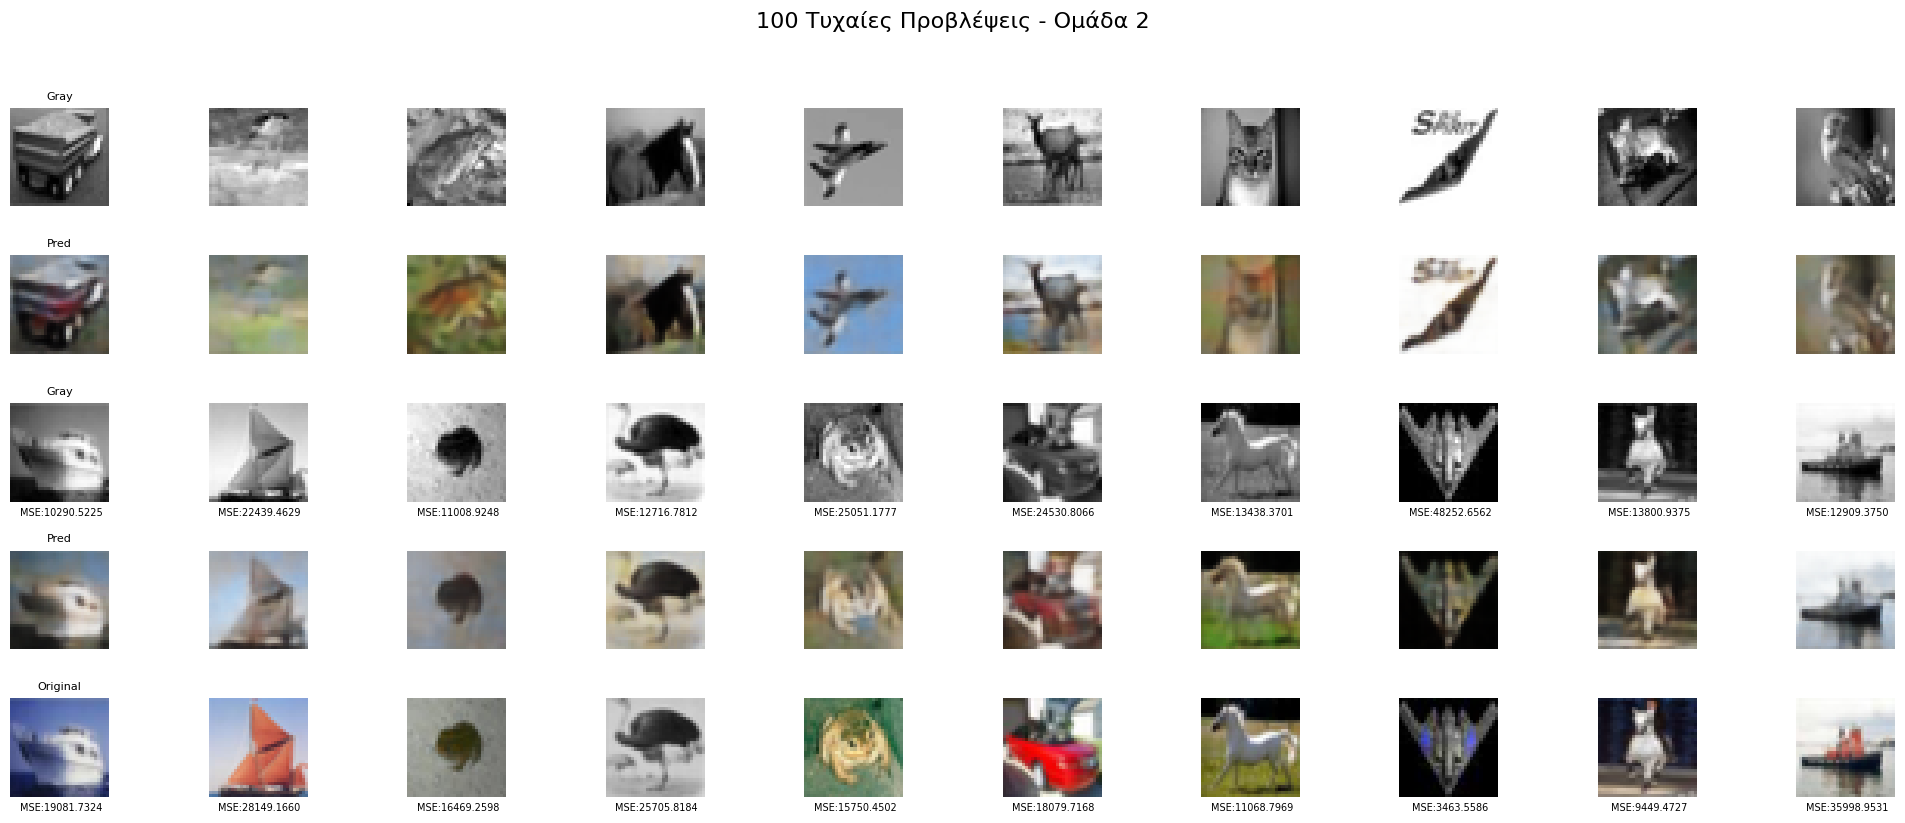

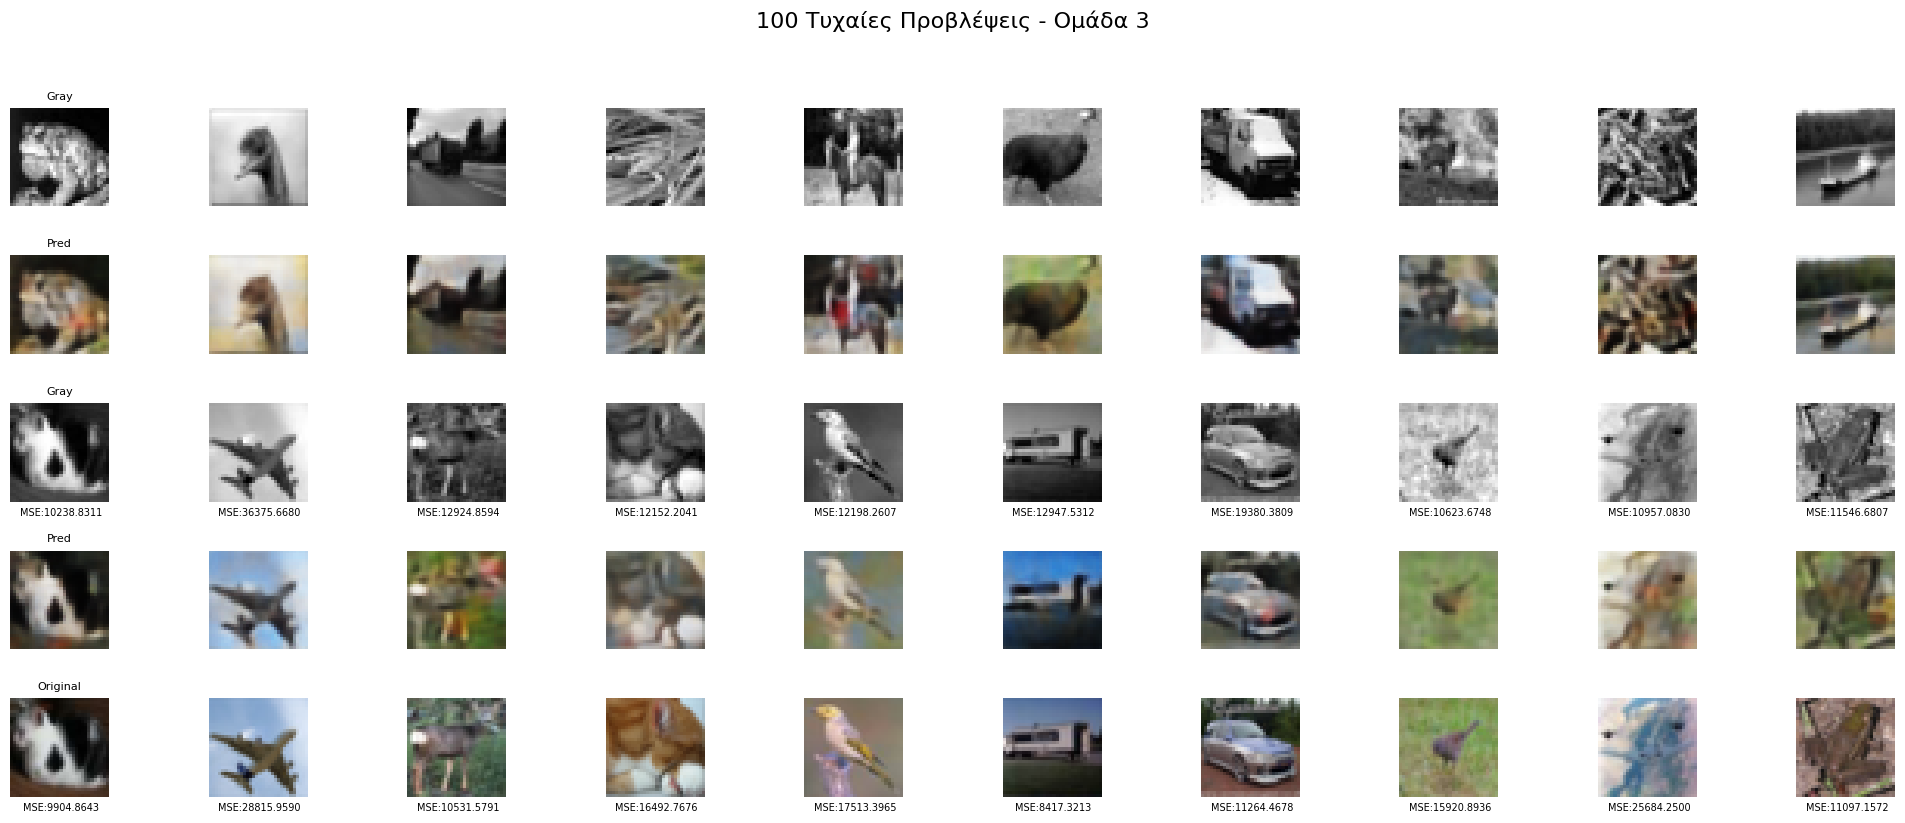

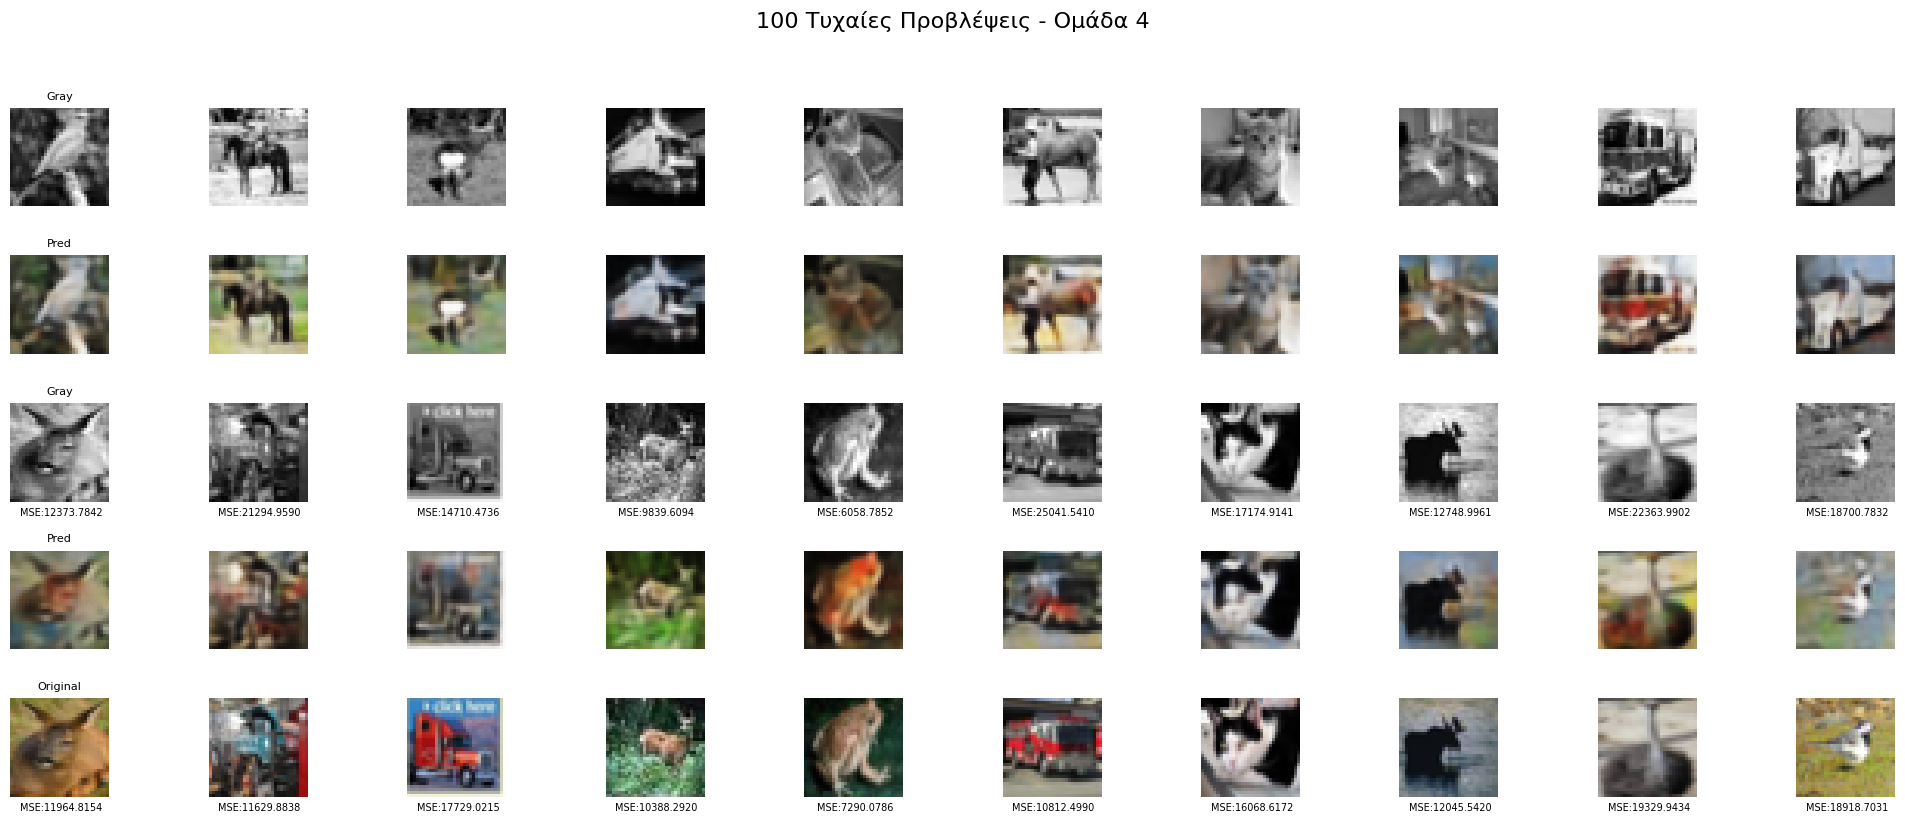

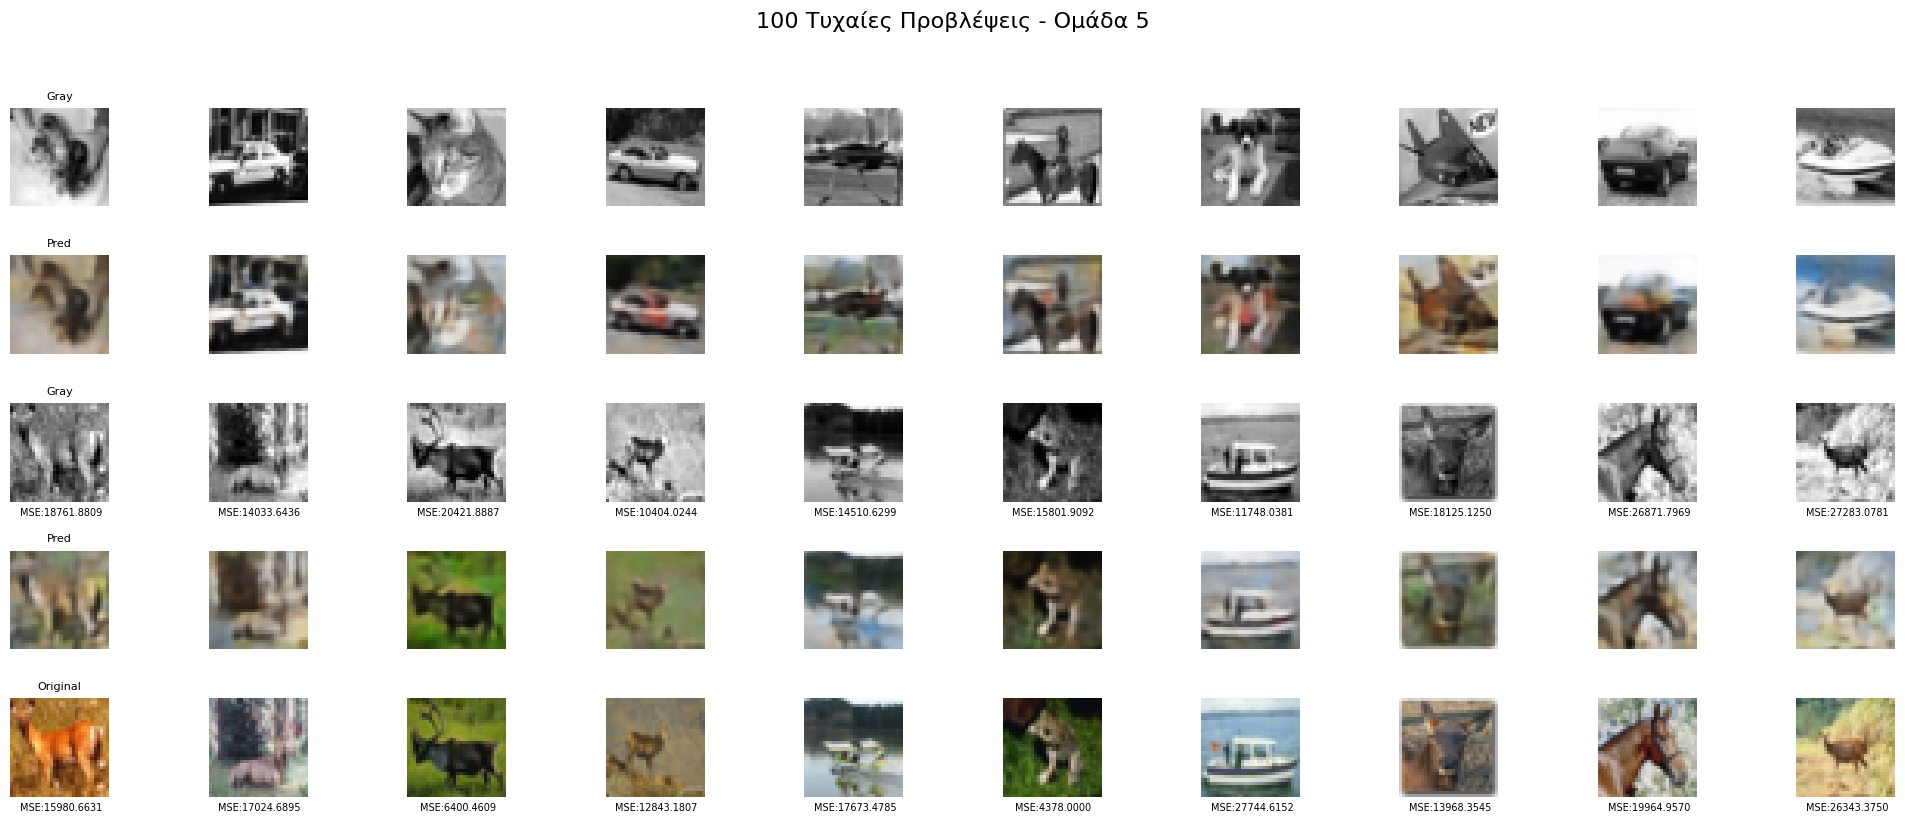

In [ ]:
import numpy as np



all_predicted = autoencoder.predict(x_test_gray)


mse_per_image = np.mean(np.square(x_test - all_predicted), axis=(1, 2, 3))


random_indices = np.random.choice(len(x_test), 100, replace=False)


def plot_random_results(indices, mse_values, images_gray, images_pred, images_true):
    images_per_fig = 20
    num_figs = 5 # 5 figs * 20 images = 100

    for fig_idx in range(num_figs):
        plt.figure(figsize=(20, 10))
        start = fig_idx * images_per_fig
        end = start + images_per_fig
        block_indices = indices[start:end]

        for i, idx in enumerate(block_indices):
            # --- Grayscale ---
            ax = plt.subplot(6, 10, i + 1 if i < 10 else i + 11)
            plt.imshow(images_gray[idx].reshape(32, 32), cmap='gray')
            plt.axis('off')
            if i == 0 or i == 10: plt.title("Gray", fontsize=8)

            # --- Predicted ---
            ax = plt.subplot(6, 10, i + 11 if i < 10 else i + 21)
            plt.imshow(images_pred[idx])
            plt.axis('off')
            if i == 0 or i == 10: plt.title("Pred", fontsize=8)

            # --- Original ---
            ax = plt.subplot(6, 10, i + 21 if i < 10 else i + 31)
            plt.imshow(images_true[idx])
            plt.axis('off')
            if i == 0 or i == 10: plt.title("Original", fontsize=8)


            plt.text(16, 36, f"MSE:{mse_values[idx]:.4f}",
                     ha='center', fontsize=7, transform=ax.transData)

        plt.suptitle(f"100 Τυχαίες Προβλέψεις - Ομάδα {fig_idx + 1}", fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()


plot_random_results(random_indices, mse_per_image, x_test_gray, all_predicted, x_test)